In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

In [3]:
df = pd.read_csv("diabetes.csv")
print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [4]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv("diabetes.csv", names=columns)

In [5]:
print(df.head())
print(df.columns)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35        0  33.6   
2            1       85             66             29        0  26.6   
3            8      183             64              0        0  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [6]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(X.shape)
print(y.shape)

(769, 8)
(769,)


In [8]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 5.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 8.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 9.5 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.5 MB 7.5 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/36.5 MB 8.8 MB/s eta 0:00:04
   ------ --------------------------------- 5.8/36.5 MB 9.5 MB/s eta 0:00:04
   -------- ------------------------------- 7.6/36.5 MB 9.4 MB/s eta 0:00:04
   ---------- ----------------------------- 9.7/36.5 MB 9.6 MB/s eta 0:00:03
   ------------- -------------------------- 12.1/36.5 MB 9.9 MB/s eta 0:00:03
   --------------- --

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(615, 8)
(154, 8)


In [11]:
# Remove wrong header row from entire dataframe
df = df[df['Pregnancies'] != 'Pregnancies']

# Convert all columns to numeric
df = df.apply(pd.to_numeric)

# Create features and target again
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=8))

model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

c:\Users\USER\miniforge3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6191 - loss: 0.6838 - val_accuracy: 0.6260 - val_loss: 0.6971
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6436 - loss: 0.6491 - val_accuracy: 0.6260 - val_loss: 0.6705
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6660 - loss: 0.6199 - val_accuracy: 0.6098 - val_loss: 0.6465
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6802 - loss: 0.5950 - val_accuracy: 0.6260 - val_loss: 0.6268
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6843 - loss: 0.5746 - val_accuracy: 0.6260 - val_loss: 0.6070
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6925 - loss: 0.5566 - val_accuracy: 0.6179 - val_loss: 0.5894
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7006 - loss: 0.5423 - val_accuracy: 0.6260 - val_loss: 0.5714
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7149 - loss: 0.5283 - val_accuracy: 0.6748 - val_loss

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)
print( accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7727 - loss: 0.5747 
0.7727272510528564


In [19]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print(cm)

acc = accuracy_score(y_test, y_pred)
print(acc)

[[82 17]
 [18 37]]
0.7727272727272727


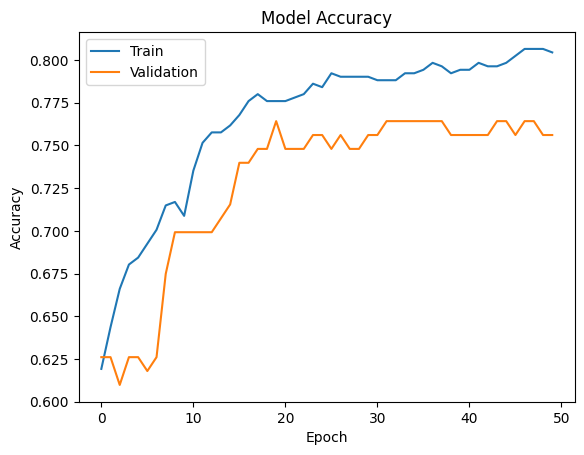

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()